# Relationship analysis
**KrishiDrishti** | Phases 4-6

Environment & resource analysis, Crop x Season and State x Season comparisons, correlations and statistical tests.

> Status: skeleton only. No analysis has been run yet.

In [2]:
# Setup: make the project root importable, then load the shared helpers
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.data_loader import load_raw
from src.io_utils import save_figure, save_table

pd.set_option("display.max_columns", 50)
df_raw = load_raw()          # untouched raw data
print(df_raw.shape)

(4000, 28)


In [5]:
df = df_raw.copy()
print(df.shape)
df.head()

(4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,7.26,5.00,5.72,4.67
Rabi,6.21,5.10,3.94,5.36
Zaid,5.85,4.03,3.06,6.17


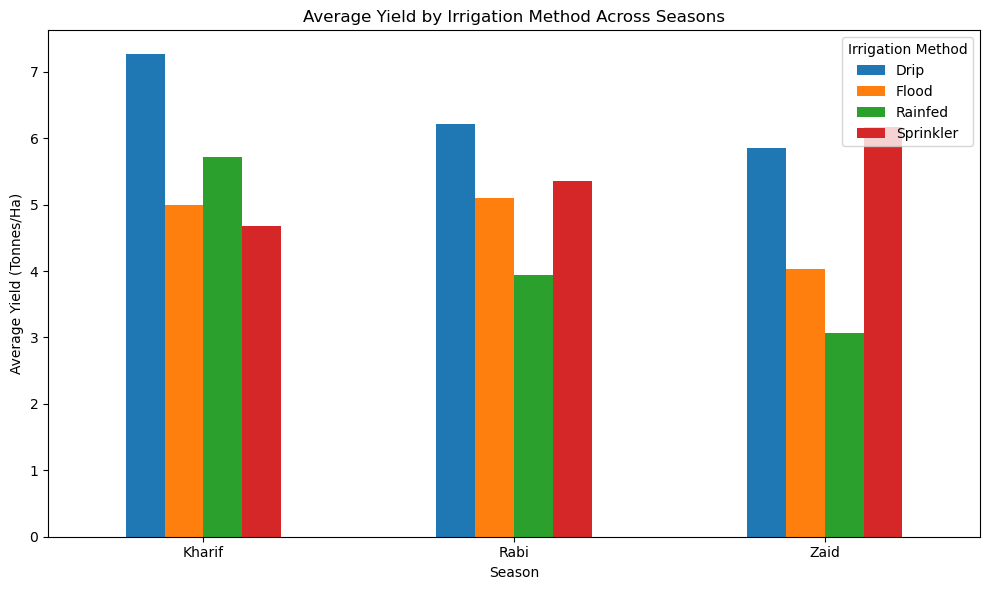

In [6]:
irrigation_season_yield = (
    df.groupby(["Season", "Irrigation_Method"])["Yield_Tonnes_Ha"]
      .mean()
      .unstack()
      .round(2)
)

display(irrigation_season_yield)

irrigation_season_yield.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Yield by Irrigation Method Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.legend(title="Irrigation Method")

plt.tight_layout()
plt.show()

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Crop,,,,
Chilli,1.72,1.49,1.44,1.50
Cotton,1.42,1.17,1.11,1.25
Groundnut,1.32,1.35,1.28,1.31
Maize,2.80,2.79,2.48,2.84
Pulses,1.05,0.88,0.86,0.89
Rice,2.77,2.24,2.36,2.49
Sugarcane,55.12,46.87,40.53,44.37
Wheat,2.30,2.03,1.98,2.23


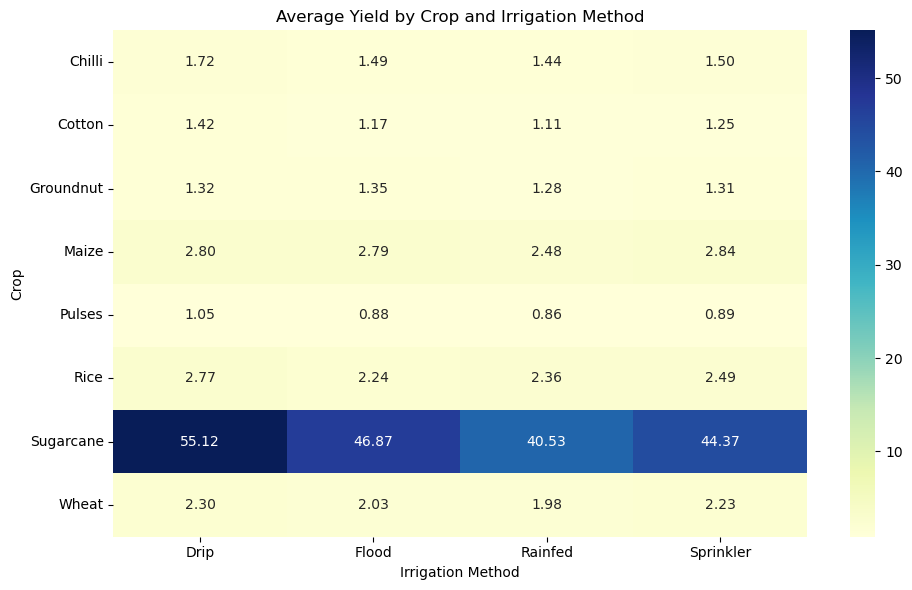

In [7]:
crop_irrigation_yield = (
    df.groupby(["Crop", "Irrigation_Method"])["Yield_Tonnes_Ha"]
      .mean()
      .unstack()
      .round(2)
)

display(crop_irrigation_yield)

plt.figure(figsize=(10, 6))
sns.heatmap(
    crop_irrigation_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Yield by Crop and Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [9]:
from scipy.stats import kruskal

groups = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in df.groupby("Irrigation_Method")
]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis statistic: {stat:.3f}")
print(f"p-value: {p_value:.6f}")

Kruskal-Wallis statistic: 22.439
p-value: 0.000053
